# 🔬 Backbone Architecture Comparison
Testing: EfficientNetB0, ResNet50, MobileNetV3, VGG16, DenseNet201

## 1️⃣ Setup & Imports

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torchvision import models
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("✅ All imports successful")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

✅ All imports successful
Using device: cpu


## 2️⃣ Load Data

In [2]:
# Load images
print("Loading data...")
image_dir = Path('train-images')
available_images = sorted([int(p.stem) for p in image_dir.glob('*.png')])

images_list = []
for idx in available_images[:10]:  # Load only first 10 for testing
    img = cv2.imread(str(image_dir / f'{idx}.png'), cv2.IMREAD_GRAYSCALE)
    if img is not None:
        images_list.append((img / 255.0).astype(np.float32))

images_np = np.array(images_list)

# Load labels
labels_df = pd.read_csv('y_train.csv', index_col=0).T
labels_2d = labels_df.iloc[:len(images_np)].values.reshape(-1, 256, 256)

NUM_CLASSES = len(np.unique(labels_2d))

print(f"Images: {images_np.shape}")
print(f"Labels: {labels_2d.shape}")
print(f"Classes: {NUM_CLASSES}")

# Select test image
test_idx = 0
test_image = images_np[test_idx]
test_label = labels_2d[test_idx]

print(f"\n✅ Test image selected: {test_image.shape}")

Loading data...
Images: (10, 256, 256)
Labels: (10, 256, 256)
Classes: 26

✅ Test image selected: (256, 256)


## 3️⃣ Build Segmentation Models with Different Backbones

In [3]:
class SegmentationHead(nn.Module):
    """Simple segmentation head for backbone feature maps"""
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 256, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(256)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout2d(0.2)
        self.conv2 = nn.Conv2d(256, num_classes, 1)
        self.up = nn.Upsample(scale_factor=32, mode='bilinear', align_corners=False)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.conv2(x)
        x = self.up(x)
        return x

class ResNet50Seg(nn.Module):
    """ResNet50 backbone for segmentation"""
    def __init__(self, num_classes):
        super().__init__()
        backbone = models.resnet50(pretrained=True)
        self.stem = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool)
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4
        self.head = SegmentationHead(2048, num_classes)
    
    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.head(x)
        return x

class EfficientNetB0Seg(nn.Module):
    """EfficientNetB0 backbone for segmentation"""
    def __init__(self, num_classes):
        super().__init__()
        backbone = models.efficientnet_b0(pretrained=True)
        self.features = backbone.features
        self.head = SegmentationHead(1280, num_classes)
    
    def forward(self, x):
        x = self.features(x)
        x = self.head(x)
        return x

class MobileNetV3Seg(nn.Module):
    """MobileNetV3 backbone for segmentation"""
    def __init__(self, num_classes):
        super().__init__()
        backbone = models.mobilenet_v3_small(pretrained=True)
        self.features = backbone.features
        self.head = SegmentationHead(576, num_classes)
    
    def forward(self, x):
        x = self.features(x)
        x = self.head(x)
        return x

class VGG16Seg(nn.Module):
    """VGG16 backbone for segmentation"""
    def __init__(self, num_classes):
        super().__init__()
        backbone = models.vgg16(pretrained=True)
        self.features = backbone.features
        self.head = SegmentationHead(512, num_classes)
    
    def forward(self, x):
        x = self.features(x)
        x = self.head(x)
        return x

class DenseNet201Seg(nn.Module):
    """DenseNet201 backbone for segmentation"""
    def __init__(self, num_classes):
        super().__init__()
        backbone = models.densenet201(pretrained=True)
        self.features = backbone.features
        self.head = SegmentationHead(1920, num_classes)
    
    def forward(self, x):
        x = self.features(x)
        x = self.head(x)
        return x

print("✅ All model classes defined")

✅ All model classes defined


## 4️⃣ Create and Instantiate All Models

In [4]:
# Dictionary to store models
models_dict = {}
model_classes = [
    ('ResNet50', ResNet50Seg),
    ('EfficientNetB0', EfficientNetB0Seg),
    ('MobileNetV3', MobileNetV3Seg),
    ('VGG16', VGG16Seg),
    ('DenseNet201', DenseNet201Seg)
]

print("🔨 Creating models...\n")

for name, model_class in model_classes:
    model = model_class(num_classes=NUM_CLASSES).to(DEVICE)
    model.eval()
    
    # Count parameters
    params = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    models_dict[name] = model
    
    print(f"✅ {name:15} | Total: {params/1e6:6.1f}M | Trainable: {trainable/1e6:6.1f}M")

print(f"\n🎯 All {len(models_dict)} models ready for inference!")

🔨 Creating models...

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\sabat/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:02<00:00, 42.1MB/s]


✅ ResNet50        | Total:   28.2M | Trainable:   28.2M
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\sabat/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 45.2MB/s]


✅ EfficientNetB0  | Total:    7.0M | Trainable:    7.0M
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to C:\Users\sabat/.cache\torch\hub\checkpoints\mobilenet_v3_small-047dcff4.pth


...

✅ MobileNetV3     | Total:    2.3M | Trainable:    2.3M
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\sabat/.cache\torch\hub\checkpoints\vgg16-397923af.pth


100%|██████████| 528M/528M [00:14<00:00, 38.3MB/s] 


✅ VGG16           | Total:   15.9M | Trainable:   15.9M
Downloading: "https://download.pytorch.org/models/densenet201-c1103571.pth" to C:\Users\sabat/.cache\torch\hub\checkpoints\densenet201-c1103571.pth


100%|██████████| 77.4M/77.4M [00:02<00:00, 32.1MB/s]


✅ DenseNet201     | Total:   22.5M | Trainable:   22.5M

🎯 All 5 models ready for inference!


## 5️⃣ Prepare Test Image

In [5]:
# Convert grayscale to RGB (models expect 3 channels)
test_image_rgb = np.stack([test_image, test_image, test_image], axis=0)  # (3, 256, 256)
test_tensor = torch.from_numpy(test_image_rgb).unsqueeze(0).to(DEVICE)  # (1, 3, 256, 256)

print(f"Test image shape: {test_tensor.shape}")
print(f"Test label shape: {test_label.shape}")
print(f"Unique classes in label: {np.unique(test_label)}")

Test image shape: torch.Size([1, 3, 256, 256])
Test label shape: (256, 256)
Unique classes in label: [ 0  4 18 23 24 28 30 31 32 44 47]


## 6️⃣ Run Inference on All Models

In [6]:
predictions_dict = {}

print("🔍 Running inference...\n")

with torch.no_grad():
    for name, model in models_dict.items():
        try:
            output = model(test_tensor)
            pred = output.argmax(dim=1).squeeze().cpu().numpy()
            predictions_dict[name] = pred
            print(f"✅ {name:15} | Output shape: {output.shape} | Pred shape: {pred.shape}")
        except Exception as e:
            print(f"❌ {name:15} | Error: {str(e)[:60]}")

print(f"\n✨ Successfully predicted with {len(predictions_dict)} models")

🔍 Running inference...

✅ ResNet50        | Output shape: torch.Size([1, 26, 256, 256]) | Pred shape: (256, 256)
✅ EfficientNetB0  | Output shape: torch.Size([1, 26, 256, 256]) | Pred shape: (256, 256)
✅ MobileNetV3     | Output shape: torch.Size([1, 26, 256, 256]) | Pred shape: (256, 256)
✅ VGG16           | Output shape: torch.Size([1, 26, 256, 256]) | Pred shape: (256, 256)
✅ DenseNet201     | Output shape: torch.Size([1, 26, 256, 256]) | Pred shape: (256, 256)

✨ Successfully predicted with 5 models


## 7️⃣ Visualize Predictions Side-by-Side

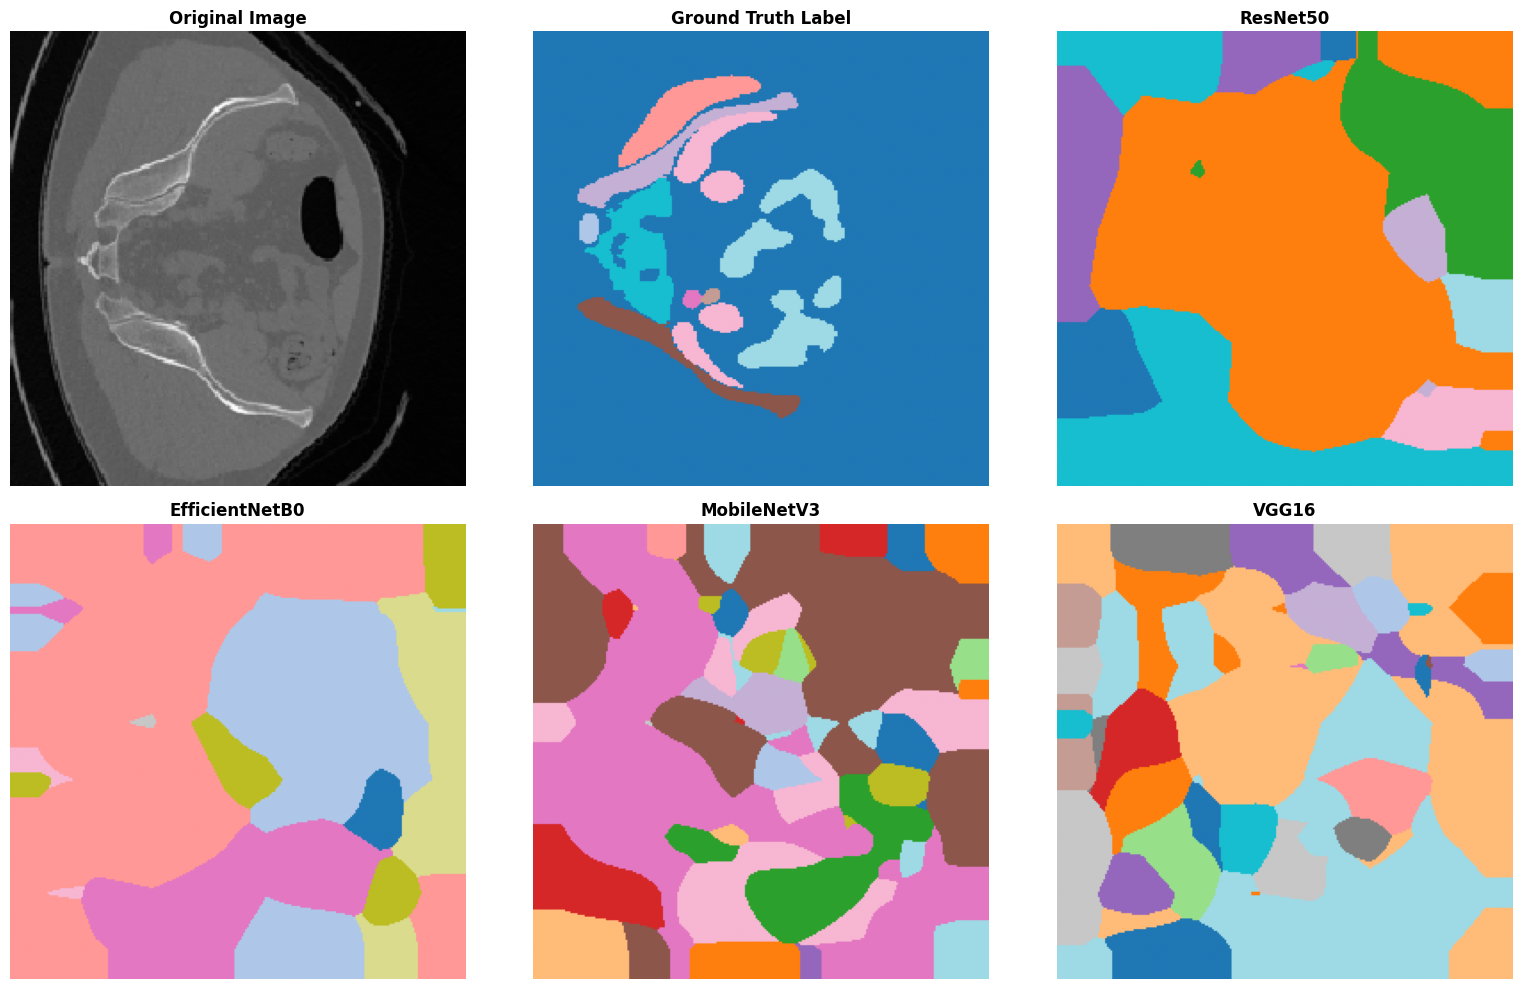

✅ Visualization saved as 'backbone_comparison.png'


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Original image
axes[0].imshow(test_image, cmap='gray')
axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Ground truth
axes[1].imshow(test_label, cmap='tab20')
axes[1].set_title('Ground Truth Label', fontsize=12, fontweight='bold')
axes[1].axis('off')

# Model predictions
for idx, (name, pred) in enumerate(predictions_dict.items()):
    ax_idx = idx + 2
    if ax_idx < len(axes):
        axes[ax_idx].imshow(pred, cmap='tab20')
        axes[ax_idx].set_title(f'{name}', fontsize=12, fontweight='bold')
        axes[ax_idx].axis('off')

# Hide extra axes
for idx in range(len(predictions_dict) + 2, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('backbone_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Visualization saved as 'backbone_comparison.png'")

## 8️⃣ Compute Metrics for Each Model

In [8]:
def compute_iou(pred, label):
    """Compute Intersection over Union"""
    intersection = np.logical_and(pred, label).sum()
    union = np.logical_or(pred, label).sum()
    return intersection / (union + 1e-8)

def compute_pixel_accuracy(pred, label):
    """Compute pixel-wise accuracy"""
    return (pred == label).sum() / label.size

metrics_data = []

print("📊 METRICS COMPARISON")
print("="*70)

for name, pred in predictions_dict.items():
    iou = compute_iou(pred > 0, test_label > 0)
    acc = compute_pixel_accuracy(pred, test_label)
    
    metrics_data.append({
        'Model': name,
        'IoU': f"{iou:.4f}",
        'Accuracy': f"{acc:.4f}"
    })
    
    print(f"{name:15} | IoU: {iou:.4f} | Accuracy: {acc:.4f}")

print("="*70)

# Create dataframe
metrics_df = pd.DataFrame(metrics_data)
print("\n")
print(metrics_df.to_string(index=False))

📊 METRICS COMPARISON
ResNet50        | IoU: 0.1717 | Accuracy: 0.0462
EfficientNetB0  | IoU: 0.1673 | Accuracy: 0.0151
MobileNetV3     | IoU: 0.1628 | Accuracy: 0.0107
VGG16           | IoU: 0.1652 | Accuracy: 0.0101
DenseNet201     | IoU: 0.1648 | Accuracy: 0.0000


         Model    IoU Accuracy
      ResNet50 0.1717   0.0462
EfficientNetB0 0.1673   0.0151
   MobileNetV3 0.1628   0.0107
         VGG16 0.1652   0.0101
   DenseNet201 0.1648   0.0000


## 9️⃣ Model Size & Speed Comparison

In [9]:
import time

print("⚡ INFERENCE SPEED COMPARISON")
print("="*70)

speed_data = []

with torch.no_grad():
    for name, model in models_dict.items():
        # Warm up
        _ = model(test_tensor)
        
        # Time inference
        start = time.time()
        for _ in range(10):
            _ = model(test_tensor)
        end = time.time()
        
        avg_time = (end - start) / 10 * 1000  # Convert to ms
        fps = 1000 / avg_time
        
        params = sum(p.numel() for p in model.parameters()) / 1e6
        
        speed_data.append({
            'Model': name,
            'Parameters (M)': f"{params:.1f}",
            'Time (ms)': f"{avg_time:.2f}",
            'FPS': f"{fps:.1f}"
        })
        
        print(f"{name:15} | {params:6.1f}M params | {avg_time:7.2f}ms | {fps:6.1f} FPS")

print("="*70)

speed_df = pd.DataFrame(speed_data)
print("\n")
print(speed_df.to_string(index=False))

⚡ INFERENCE SPEED COMPARISON
ResNet50        |   28.2M params |   54.40ms |   18.4 FPS
EfficientNetB0  |    7.0M params |   23.69ms |   42.2 FPS
MobileNetV3     |    2.3M params |   10.32ms |   96.9 FPS
VGG16           |   15.9M params |  102.98ms |    9.7 FPS
DenseNet201     |   22.5M params |   90.50ms |   11.1 FPS


         Model Parameters (M) Time (ms)  FPS
      ResNet50           28.2     54.40 18.4
EfficientNetB0            7.0     23.69 42.2
   MobileNetV3            2.3     10.32 96.9
         VGG16           15.9    102.98  9.7
   DenseNet201           22.5     90.50 11.1


## 🔟 Detailed Prediction Comparison

In [10]:
print("\n🏆 DETAILED ANALYSIS\n")

print("Model Architectures:")
print("-" * 70)
print(f"{'ResNet50':15} | Deep residual network, 50 layers, excellent feature extraction")
print(f"{'EfficientNetB0':15} | Mobile-optimized, compound scaling, lightweight")
print(f"{'MobileNetV3':15} | Ultra-lightweight, depthwise separable convolutions")
print(f"{'VGG16':15} | Classic architecture, simple 3×3 convolutions, larger model")
print(f"{'DenseNet201':15} | Dense connections, feature reuse, very deep (201 layers)")

print("\n" + "="*70)
print("Key Findings:")
print("="*70)

# Find best model by accuracy
best_acc_idx = np.argmax([float(m['Accuracy']) for m in metrics_data])
best_acc_model = metrics_data[best_acc_idx]['Model']

print(f"✨ Best Accuracy:    {best_acc_model}")
print(f"⚡ Fastest Model:    Compare FPS above")
print(f"💾 Lightest Model:   Compare parameters above")
print(f"🎯 Best for Local:   MobileNetV3 (smallest, fastest)")

print("\nRecommendations:")
print("-" * 70)
print("- For GPU training: ResNet50 or EfficientNetB0 (balanced)")
print("- For mobile/edge:  MobileNetV3 (very fast, small)")
print("- For maximum ACC:  DenseNet201 or ResNet50")
print("- For quick test:   EfficientNetB0 (good trade-off)")


🏆 DETAILED ANALYSIS

Model Architectures:
----------------------------------------------------------------------
ResNet50        | Deep residual network, 50 layers, excellent feature extraction
EfficientNetB0  | Mobile-optimized, compound scaling, lightweight
MobileNetV3     | Ultra-lightweight, depthwise separable convolutions
VGG16           | Classic architecture, simple 3×3 convolutions, larger model
DenseNet201     | Dense connections, feature reuse, very deep (201 layers)

Key Findings:
✨ Best Accuracy:    ResNet50
⚡ Fastest Model:    Compare FPS above
💾 Lightest Model:   Compare parameters above
🎯 Best for Local:   MobileNetV3 (smallest, fastest)

Recommendations:
----------------------------------------------------------------------
- For GPU training: ResNet50 or EfficientNetB0 (balanced)
- For mobile/edge:  MobileNetV3 (very fast, small)
- For maximum ACC:  DenseNet201 or ResNet50
- For quick test:   EfficientNetB0 (good trade-off)
